In [4]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter

# Reprodukowalność
np.random.seed(42)

# Wyświetlanie
pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 100

print("Setup OK")

Setup OK


In [14]:
# Wczytaj plik — pomiń puste wiersze na początku
df_raw = pd.read_excel('../data/subscribers.xlsx', header=None)

# Znajdź wiersz z nagłówkami (ten zawierający 'Age')
header_row = df_raw[df_raw.apply(lambda row: 'Age' in row.values, axis=1)].index[0]

# Wczytaj ponownie z prawidłowym nagłówkiem
df = pd.read_excel('../data/subscribers.xlsx', skiprows=header_row + 1, 
                    header=None,
                    names=['Age', 'Sex', 'Income', 'Residence', 'Subscribes'])

# Wyczyść puste wiersze
df = df.dropna(how='all').reset_index(drop=True)
df['Subscribes'] = df['Subscribes'].astype(int)

print(f"Kształt: {df.shape}")
print(f"Kolumny: {df.columns.tolist()}")
df.head(10)

Kształt: (1024, 5)
Kolumny: ['Age', 'Sex', 'Income', 'Residence', 'Subscribes']


,Age,Sex,Income,Residence,Subscribes
0,senior,M,low,country,1
1,young adult,M,low,suburb,0
2,gen. X,F,low,suburb,0
3,young adult,F,low,suburb,0
4,gen. X,M,high,city,1
5,gen. X,M,low,city,1
6,young adult,F,low,country,0
7,young adult,F,low,city,1
8,gen. X,F,low,city,0
9,young adult,F,average,city,1


In [16]:
print("── Typy kolumn ──")
print(df.dtypes)

print("\n── Braki danych ──")
print(df.isnull().sum())

print("\n── Unikalne wartości w każdej kolumnie ──")
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"  {col}: {unique_vals}")

print("\n── Rozkład klasy docelowej (Subscribes) ──")
counts = df['Subscribes'].value_counts()
print(counts)
print(f"\nBalans: {(counts / len(df) * 100).round(1).to_dict()} %")

── Typy kolumn ──
Age             str
Sex             str
Income          str
Residence       str
Subscribes    int64
dtype: object

── Braki danych ──
Age           0
Sex           0
Income        0
Residence     0
Subscribes    0
dtype: int64

── Unikalne wartości w każdej kolumnie ──
  Age: <StringArray>
['senior', 'young adult', 'gen. X', 'adult']
Length: 4, dtype: str
  Sex: <StringArray>
['M', 'F']
Length: 2, dtype: str
  Income: <StringArray>
['low', 'high', 'average']
Length: 3, dtype: str
  Residence: <StringArray>
['country', 'suburb', 'city']
Length: 3, dtype: str
  Subscribes: [1 0]

── Rozkład klasy docelowej (Subscribes) ──
Subscribes
0    660
1    364
Name: count, dtype: int64

Balans: {0: 64.5, 1: 35.5} %


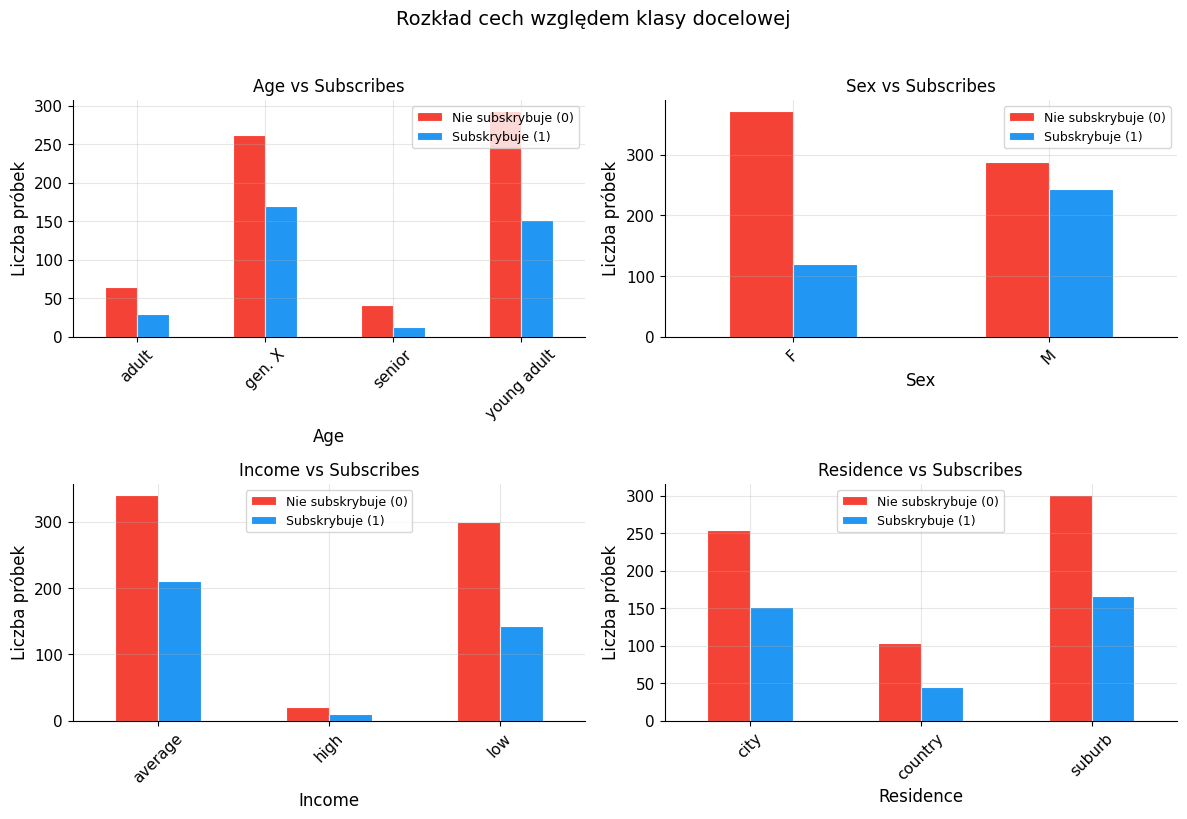

✓ Wykres zapisany do plots/bayes_features_distribution.png


In [17]:
features = ['Age', 'Sex', 'Income', 'Residence']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    crosstab = pd.crosstab(df[feature], df['Subscribes'])
    crosstab.plot(kind='bar', ax=axes[i], color=['#F44336', '#2196F3'], 
                   edgecolor='white', linewidth=0.8)
    axes[i].set_title(f'{feature} vs Subscribes', fontsize=12)
    axes[i].set_ylabel('Liczba próbek')
    axes[i].set_xlabel(feature)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(['Nie subskrybuje (0)', 'Subskrybuje (1)'], fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Rozkład cech względem klasy docelowej', fontsize=14, y=1.02)
plt.tight_layout()

# Utwórz folder plots/ jeśli nie istnieje
import os
os.makedirs('../plots', exist_ok=True)
plt.savefig('../plots/bayes_features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Wykres zapisany do plots/bayes_features_distribution.png")